In [55]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [56]:
power_law_db = pl.read_parquet(r"MLE_random_sample_fit_data\PowerLaw").filter(pl.col("min_alpha_to_consider") == 1e2).with_columns(
    (-2 * pl.col("q")).alias("b")
)
weibull_db = pl.read_parquet(r"MLE_random_sample_fit_data\Weibull").filter(pl.col("min_alpha_to_consider") == 1e2)
log_normal_db = pl.read_parquet(r"MLE_random_sample_fit_data\LogNormal").filter(pl.col("min_alpha_to_consider") == 1e2)

In [57]:
log_normal_db

seed,aic,bic,numb_alphas,s_max_fitting_alpha,s_min_fitting_alpha,LAD_min,J_min,min_alpha_to_consider,mu,sigma,mu_err,sigma_err
i32,f64,f64,i64,f64,f64,i32,f64,f64,f64,f64,f64,f64
52184,2.6007e6,2.6007e6,192734,20845.303305,23.497827,0,0.7,100.0,-17.7167,4.084135,0.913147,0.105631
58839,2.5985e6,2.5986e6,192734,34166.764882,23.497827,0,0.7,100.0,-24.309243,4.734438,1.654157,0.161622
27852,2.6174e6,2.6175e6,192734,18217.221331,23.497827,0,0.7,100.0,-18.902648,4.242869,1.060819,0.11939
87890,2.6166e6,2.6167e6,192734,18217.221331,23.497827,0,0.7,100.0,-39.792951,6.11283,4.437132,0.340956
34871,2.5986e6,2.5986e6,192734,34166.764882,23.497827,0,0.7,100.0,-12.199226,3.451489,0.461106,0.065714
…,…,…,…,…,…,…,…,…,…,…,…,…
61653,2.5956e6,2.5956e6,192734,20845.303305,22.776133,0,0.7,100.0,-11.97819,3.413267,0.444356,0.063839
54579,2.6041e6,2.6042e6,192734,20845.303305,23.497827,0,0.7,100.0,-40.895261,6.085165,4.507566,0.335862
20297,2.6000e6,2.6001e6,192734,34166.764882,22.776133,0,0.7,100.0,-13.240516,3.566964,0.533601,0.072326


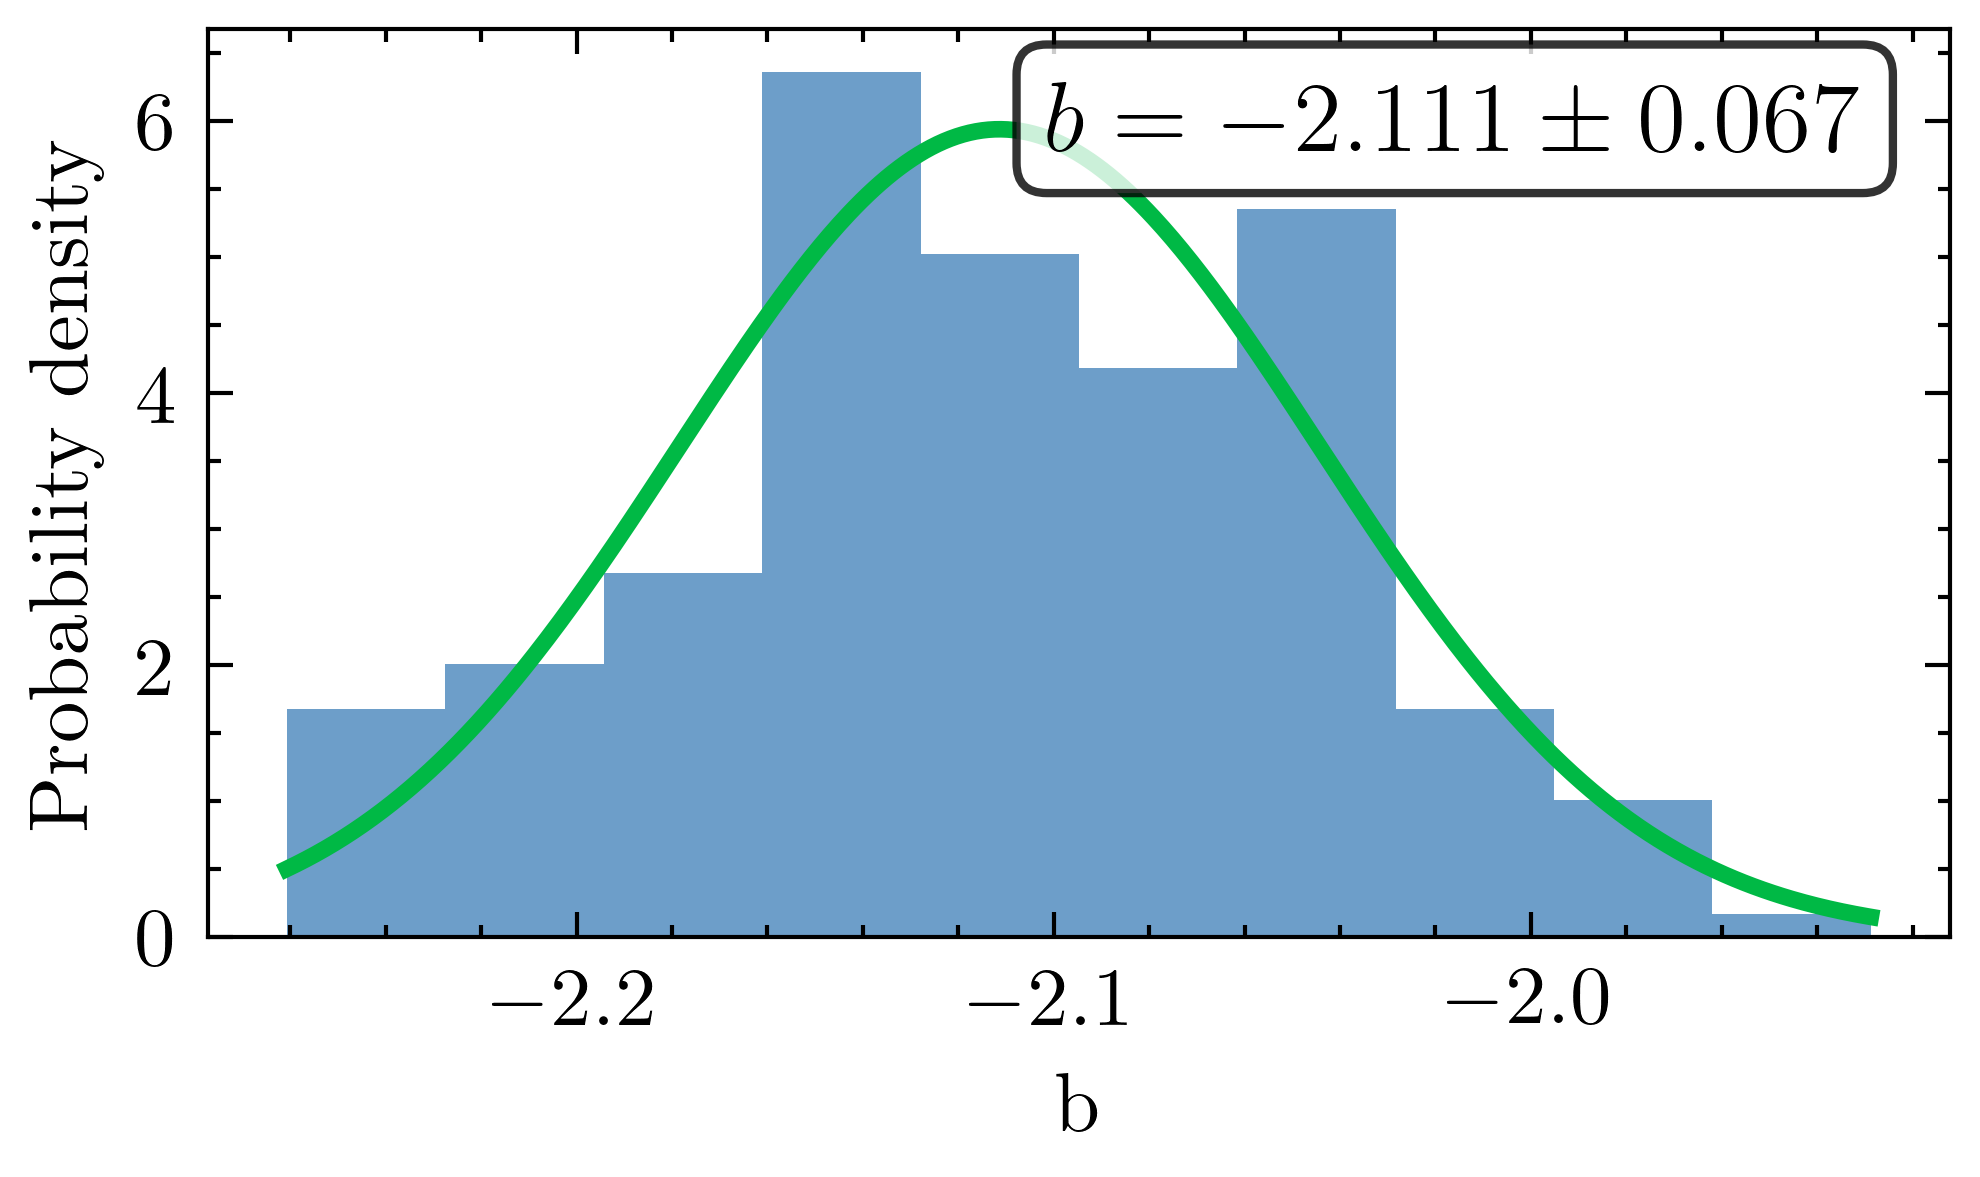

In [58]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

b_values = power_law_db['b']

# Mean and standard deviation
b_mean = b_values.mean()
b_std = b_values.std()

# Histogram
plt.hist(b_values, 10, density=True, alpha=0.6)

# Normal distribution overlay
x = np.linspace(b_values.min(), b_values.max(), 500)
plt.plot(x, norm.pdf(x, b_values.mean(), b_values.std()),
         linewidth=2)

# Labels and annotation
plt.xlabel("b")
plt.ylabel("Probability density")

plt.text(
    0.95, 0.95,
    rf"$b = {b_mean:.3f} \pm {b_std:.3f}$",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig(".plots/b.png")

plt.show()

In [59]:
def sci_latex_shared(value, error):
    exponent = int(np.floor(np.log10(abs(value))))
    coefficient = value / 10**exponent
    error_coefficient = error / 10**exponent
    return rf"({coefficient:.2f} \pm {error_coefficient:.2f})\times10^{{{exponent}}}"

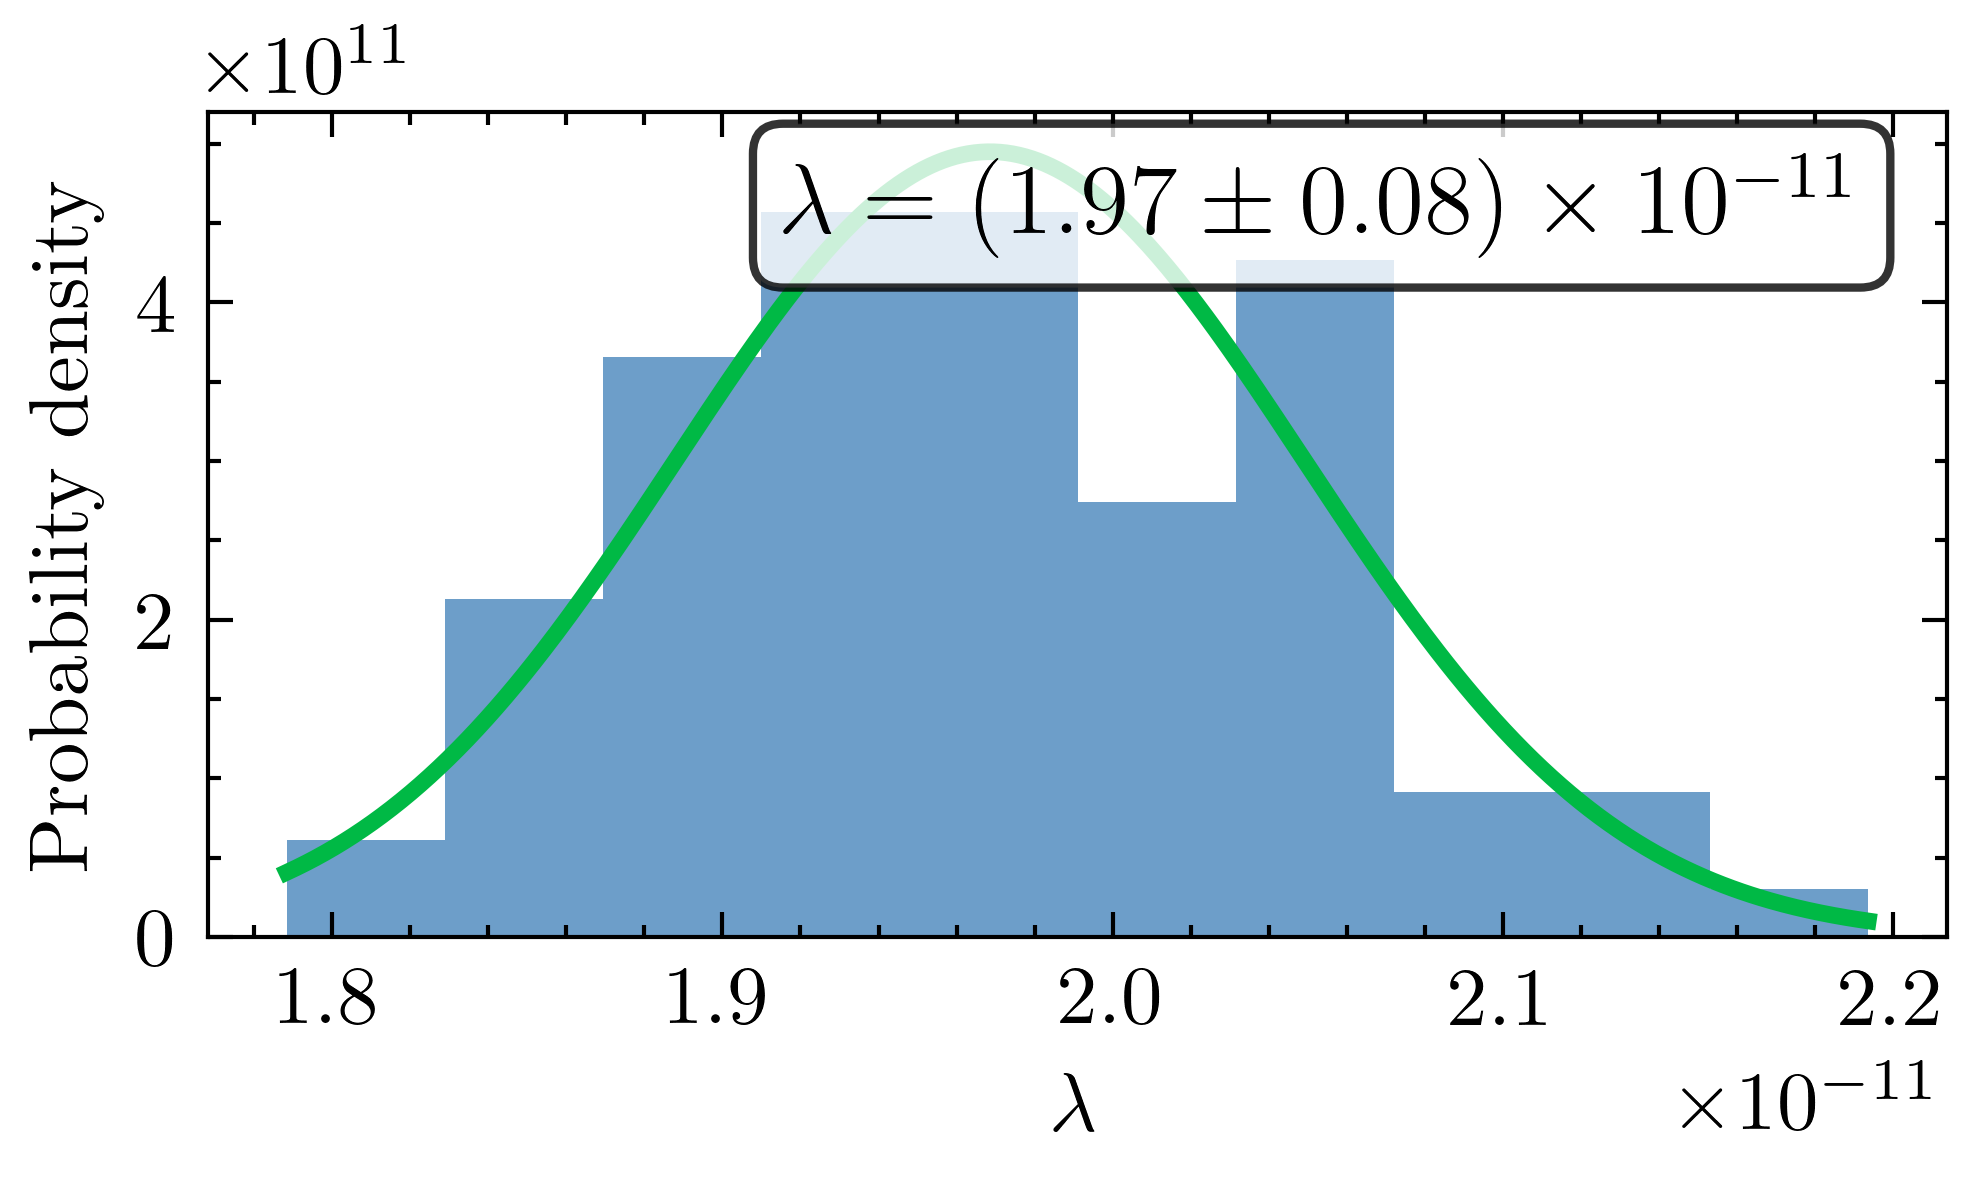

In [60]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

lambda_values = weibull_db.filter(pl.col("lambda") > 1e-11)['lambda']

# Mean and standard deviation
lambda_mean = lambda_values.mean()
lambda_std = lambda_values.std()

# Histogram
plt.hist(lambda_values, 10, density=True, alpha=0.6)

# Normal distribution overlay
x = np.linspace(lambda_values.min(), lambda_values.max(), 500)
plt.plot(x, norm.pdf(x, lambda_values.mean(), lambda_values.std()),
         linewidth=2)

# Labels and annotation
plt.xlabel(r"$\lambda$")
plt.ylabel("Probability density")

# Format values in LaTeX scientific notation
def sci_latex(value):
    exponent = int(np.floor(np.log10(abs(value))))
    coefficient = value / 10**exponent
    return rf"{coefficient:.2f}\times10^{{{exponent}}}"

plt.text(
    0.95, 0.95,
    rf"$\lambda = {sci_latex_shared(lambda_mean, lambda_std)}$",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig(".plots/lambda.png")

plt.show()

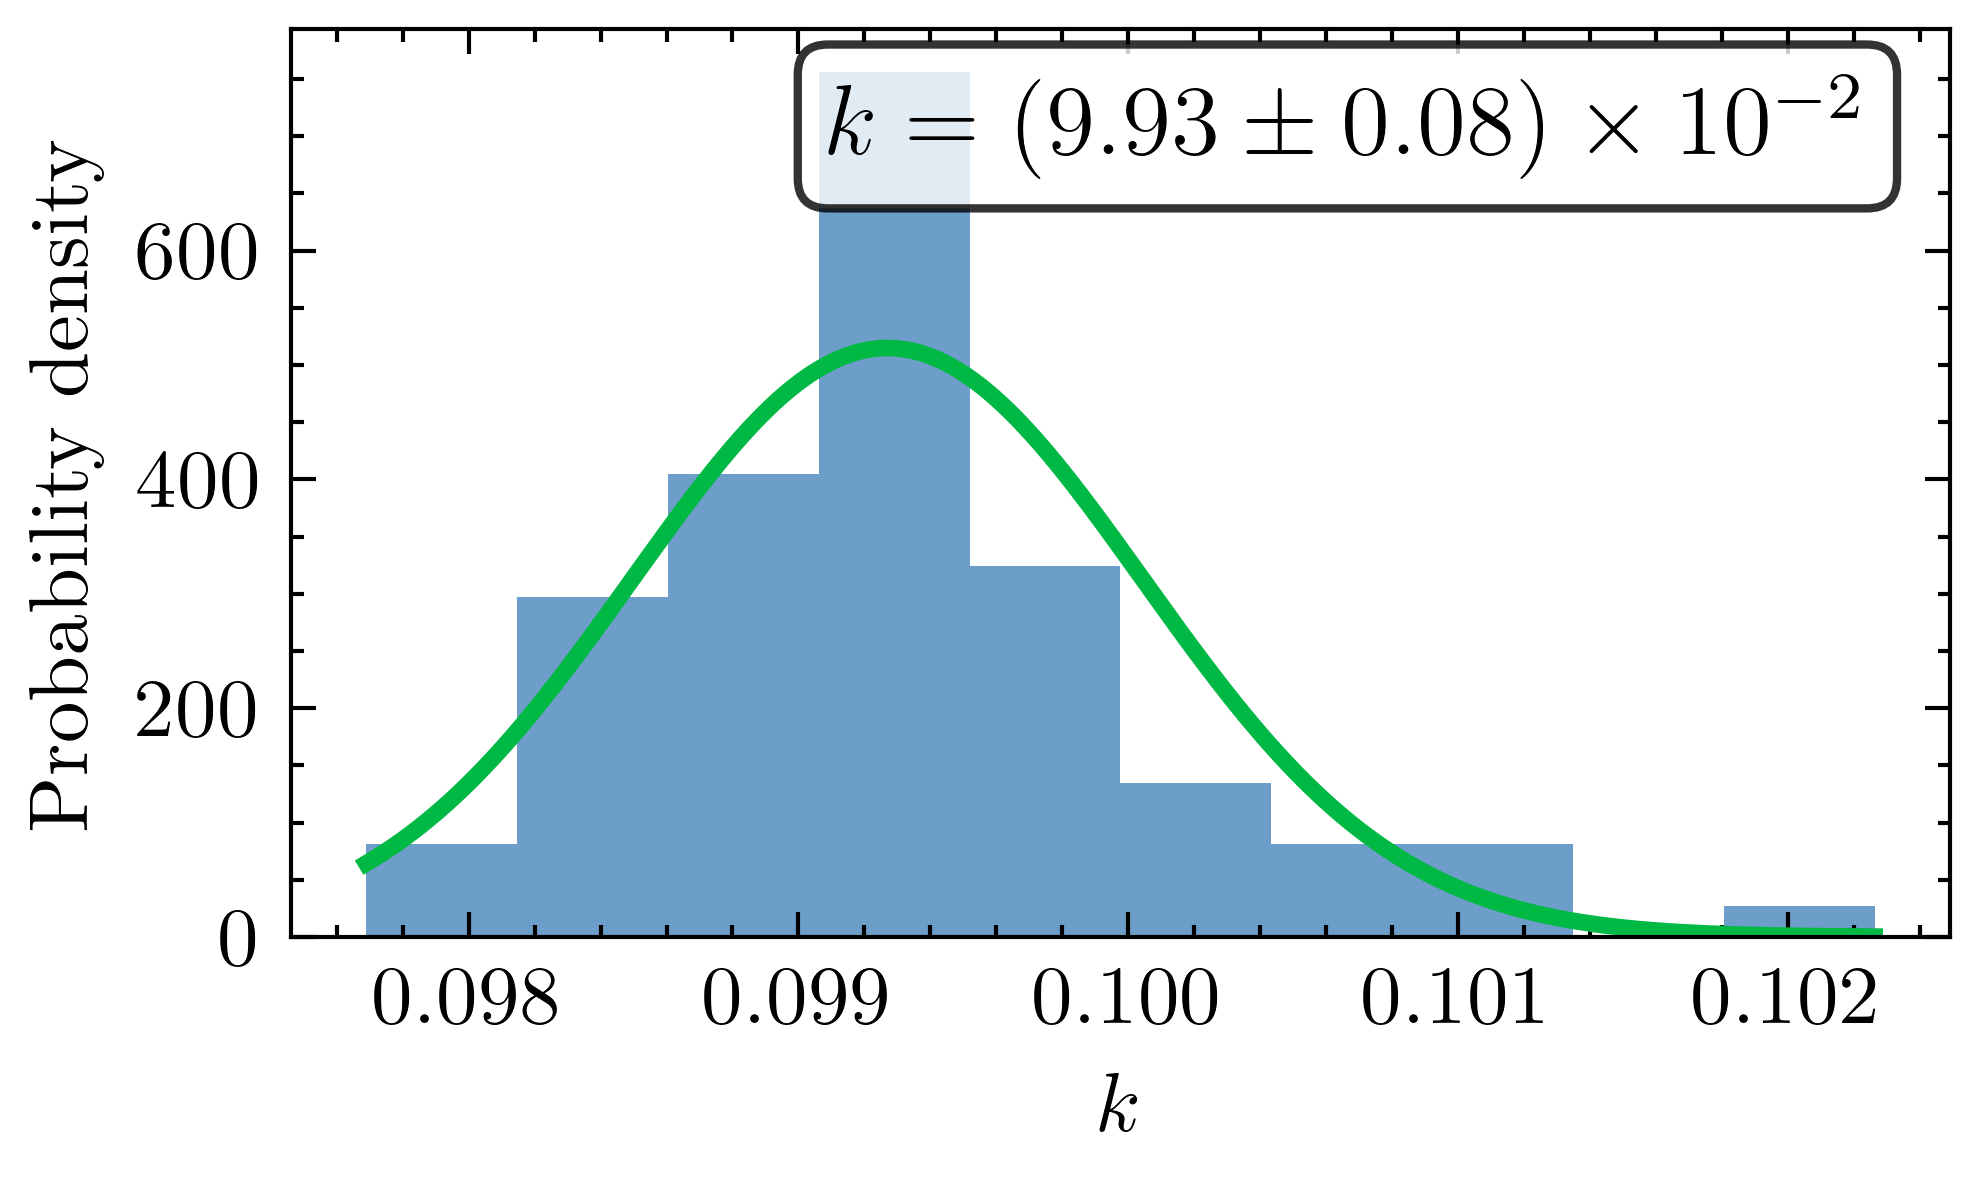

In [61]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

k_values = weibull_db.filter(pl.col("lambda") > 1e-11)['k']

# Mean and standard deviation
k_mean = k_values.mean()
k_std = k_values.std()

# Histogram
plt.hist(k_values, 10, density=True, alpha=0.6)

# Normal distribution overlay
x = np.linspace(k_values.min(), k_values.max(), 500)
plt.plot(x, norm.pdf(x, k_values.mean(), k_values.std()),
         linewidth=2)

# Labels and annotation
plt.xlabel(r"$k$")
plt.ylabel("Probability density")

# Format values as (a ± b) × 10^n
def sci_latex_shared(value, error):
    exponent = int(np.floor(np.log10(abs(value))))
    coefficient = value / 10**exponent
    error_coefficient = error / 10**exponent
    return rf"({coefficient:.2f} \pm {error_coefficient:.2f})\times10^{{{exponent}}}"

plt.text(
    0.95, 0.95,
    rf"$k = {sci_latex_shared(k_mean, k_std)}$",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig(".plots/k.png")

plt.show()

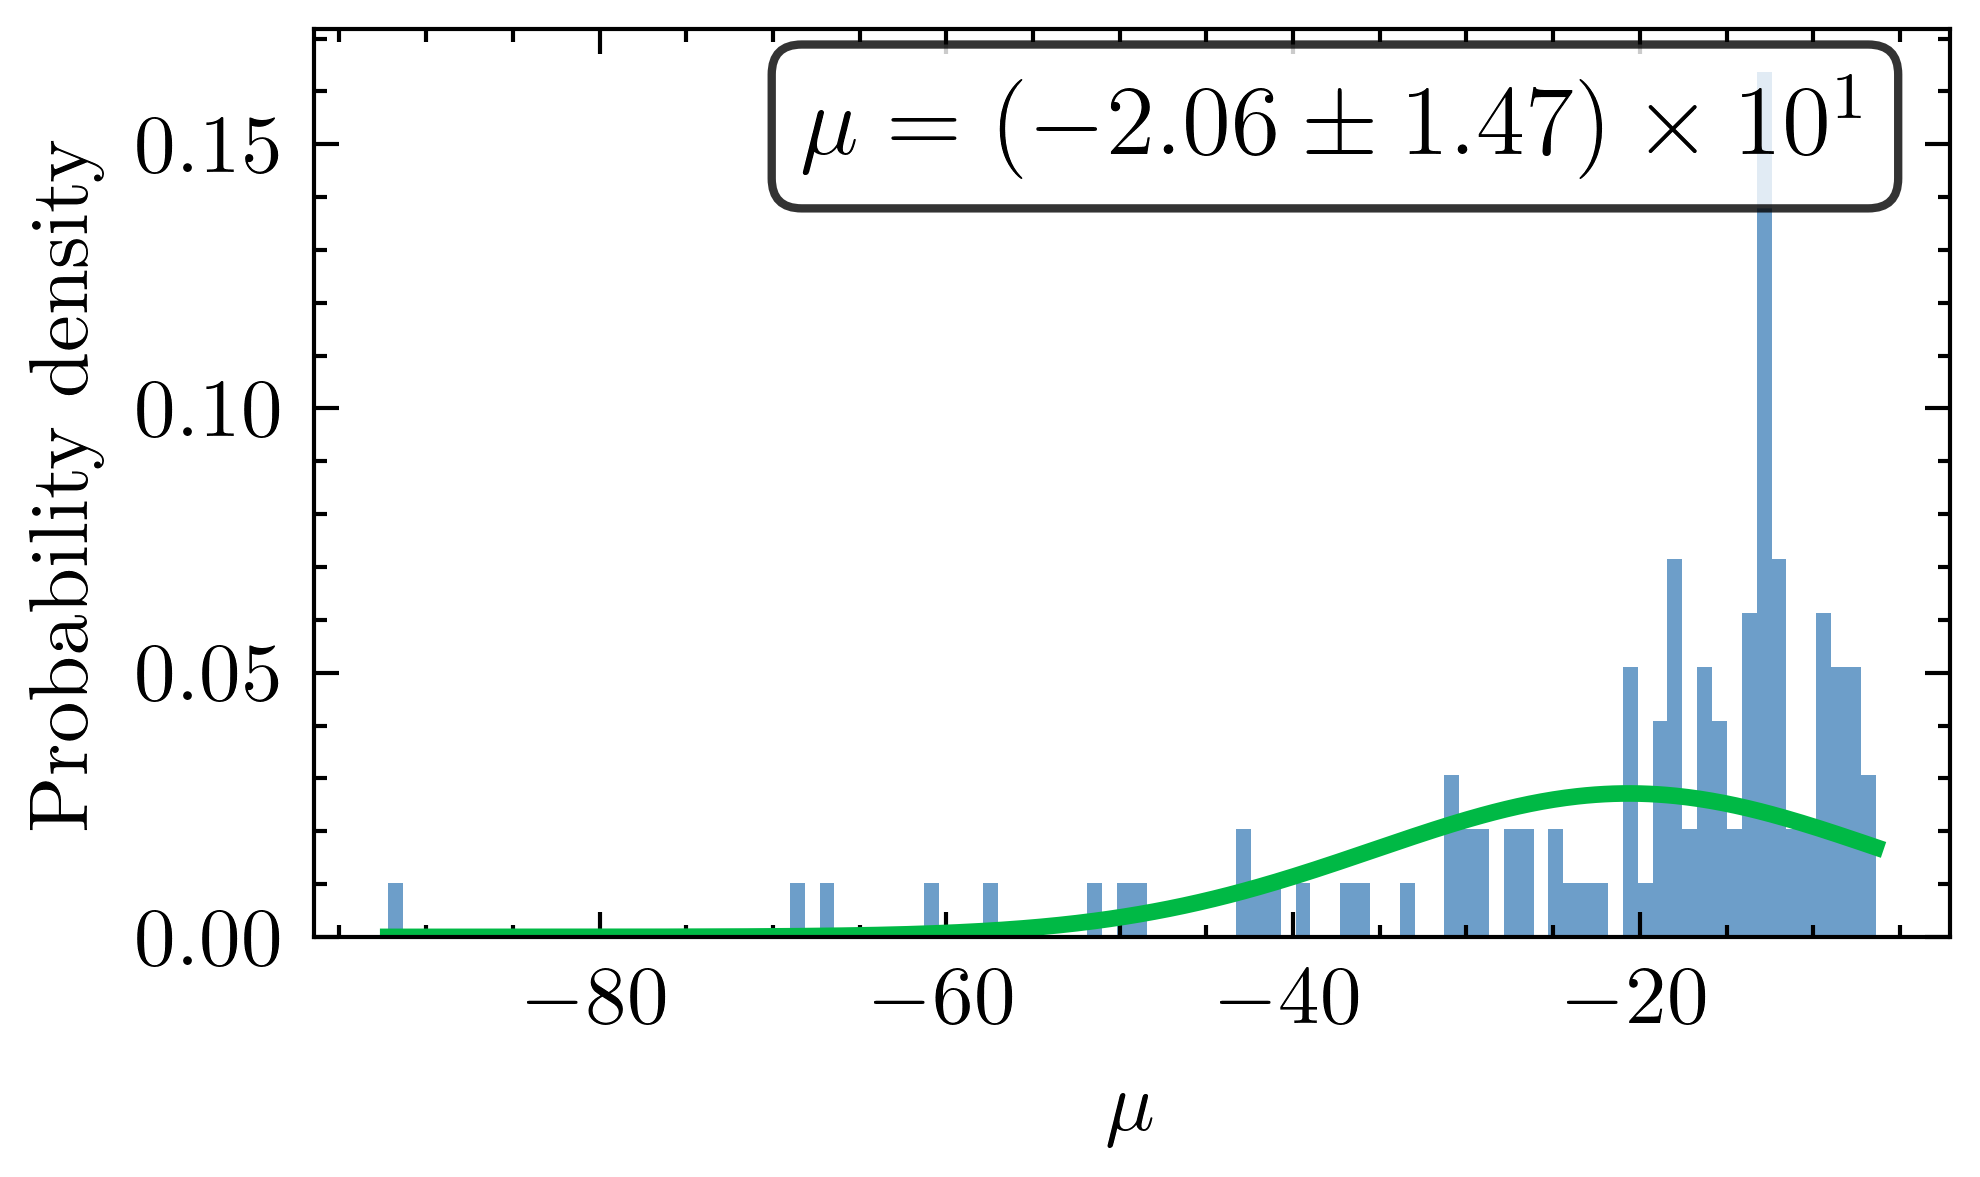

In [62]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

mu_values = log_normal_db.filter(pl.col("sigma") < 10)['mu']

# Mean and standard deviation
mu_mean = mu_values.mean()
mu_std = mu_values.std()

# Histogram
plt.hist(mu_values, 100, density=True, alpha=0.6)

# Normal distribution overlay
x = np.linspace(mu_values.min(), mu_values.max(), 500)
plt.plot(x, norm.pdf(x, mu_values.mean(), mu_values.std()),
         linewidth=2)

# Labels and annotation
plt.xlabel(r"$\mu$")
plt.ylabel("Probability density")

plt.text(
    0.95, 0.95,
    rf"$\mu = {sci_latex_shared(mu_mean, mu_std)}$",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig(".plots/mu.png")

plt.show()

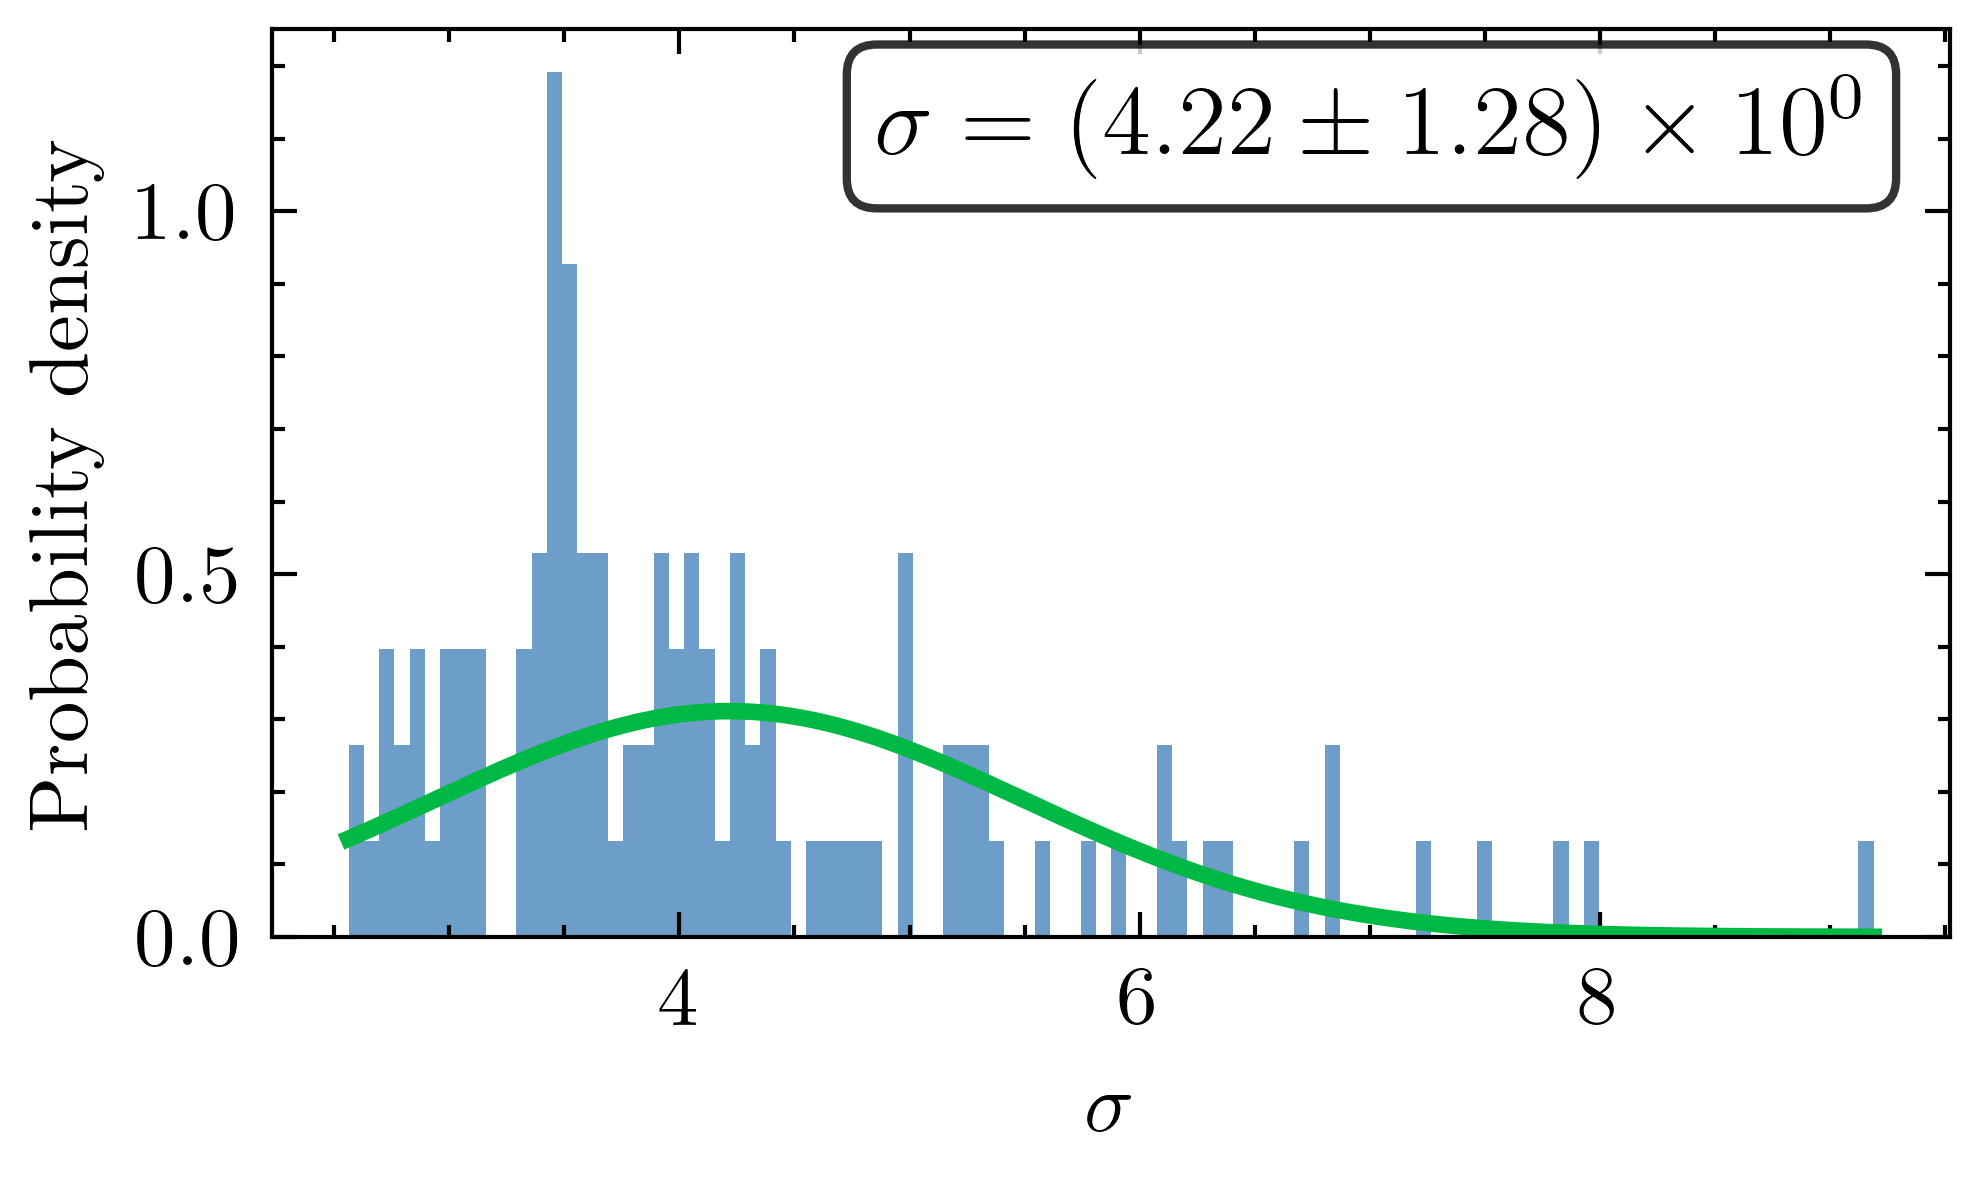

In [63]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

sigma_values = log_normal_db.filter(pl.col("sigma") < 10)['sigma']

# Mean and standard deviation
sigma_mean = sigma_values.mean()
sigma_std = sigma_values.std()

# Histogram
plt.hist(sigma_values, 100, density=True, alpha=0.6)

# Normal distribution overlay
x = np.linspace(sigma_values.min(), sigma_values.max(), 500)
plt.plot(x, norm.pdf(x, sigma_values.mean(), sigma_values.std()),
         linewidth=2)

# Labels and annotation
plt.xlabel(r"$\sigma$")
plt.ylabel("Probability density")

plt.text(
    0.95, 0.95,
    rf"$\sigma = {sci_latex_shared(sigma_mean, sigma_std)}$",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig(".plots/sigma.png")

plt.show()